In [5]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [6]:
conn = sqlite3.connect("../data/database/electromarket.db")

customers = pd.read_sql_query("SELECT * FROM customers", conn)
products = pd.read_sql_query("SELECT * FROM products", conn)
orders = pd.read_sql_query("SELECT * FROM orders", conn)
order_items = pd.read_sql_query("SELECT * FROM order_items", conn)
sessions = pd.read_sql_query("SELECT * FROM sessions", conn)
reviews = pd.read_sql_query("SELECT * FROM reviews", conn)

In [7]:
customers.head()

,customer_id,full_name,gender,age,city,registration_date,acquisition_channel
0,C00001,Аким Елизарович Николаев,Male,46,Краснодар,2025-11-10,SEO
1,C00002,Зиновьев Варфоломей Афанасьевич,Male,28,Краснодар,2025-05-21,Social Media
2,C00003,Амос Аксёнович Тарасов,Male,19,Краснодар,2025-03-16,SEO
3,C00004,Селезнева Элеонора Алексеевна,Female,50,Воронеж,2023-01-22,SEO
4,C00005,Трифон Федосеевич Поляков,Male,44,Воронеж,2024-11-30,Paid Ads


In [8]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   order_id        25000 non-null  str  
 1   customer_id     25000 non-null  str  
 2   order_date      25000 non-null  str  
 3   status          25000 non-null  str  
 4   payment_method  25000 non-null  str  
 5   delivery_type   25000 non-null  str  
dtypes: str(6)
memory usage: 1.1 MB


In [9]:
orders["order_date"] = pd.to_datetime(orders["order_date"])

sales = (
    order_items
    .merge(products, on="product_id")
    .merge(orders, on="order_id")
)

sales["revenue"] = sales["quantity"] * sales["unit_price"] * (1 - sales["discount"])
sales["profit"] = sales["revenue"] - sales["quantity"] * sales["cost"]

sales.head()

,order_item_id,order_id,product_id,quantity,unit_price,discount,product_name,category,brand,price,cost,customer_id,order_date,status,payment_method,delivery_type,revenue,profit
0,OI0000001,O000001,P00307,1,20572.16,0.05,Apple Smart Home Model 307,Smart Home,Sony,20572.16,15928.12,C01457,2025-06-29,completed,Installment,Post,19543.5520,3615.4320
1,OI0000002,O000001,P00539,1,33865.51,0.00,Lenovo Headphones Model 539,Headphones,Asus,33865.51,26918.55,C01457,2025-06-29,completed,Installment,Post,33865.5100,6946.9600
2,OI0000003,O000002,P00634,3,30617.48,0.00,LG Gaming Model 634,Gaming,Samsung,30617.48,22074.20,C04955,2023-08-24,completed,Card,Courier,91852.4400,25629.8400
3,OI0000004,O000002,P00691,1,172094.36,0.00,Lenovo TV Model 691,TV,Asus,172094.36,104085.55,C04955,2023-08-24,completed,Card,Courier,172094.3600,68008.8100
4,OI0000005,O000002,P00836,1,21019.33,0.05,Huawei Smart Home Model 836,Smart Home,Logitech,21019.33,13788.02,C04955,2023-08-24,completed,Card,Courier,19968.3635,6180.3435


In [10]:
revenue_by_category = (
    sales[sales["status"] == "completed"]
    .groupby("category", as_index=False)["revenue"]
    .sum()
    .sort_values("revenue", ascending=False)
)

revenue_by_category

,category,revenue
3,Laptops,1.465713e+09
6,TV,1.372874e+09
5,Smartphones,1.026805e+09
1,Gaming,7.155970e+08
4,Smart Home,2.886301e+08
2,Headphones,2.395082e+08
0,Accessories,8.564228e+07


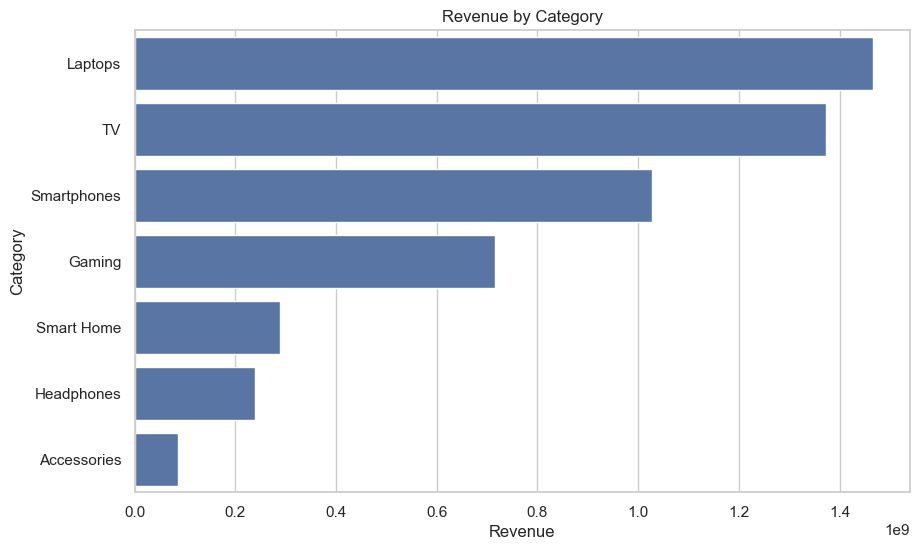

In [11]:
plt.figure(figsize=(10, 6))
sns.barplot(data=revenue_by_category, x="revenue", y="category")
plt.title("Revenue by Category")
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.show()

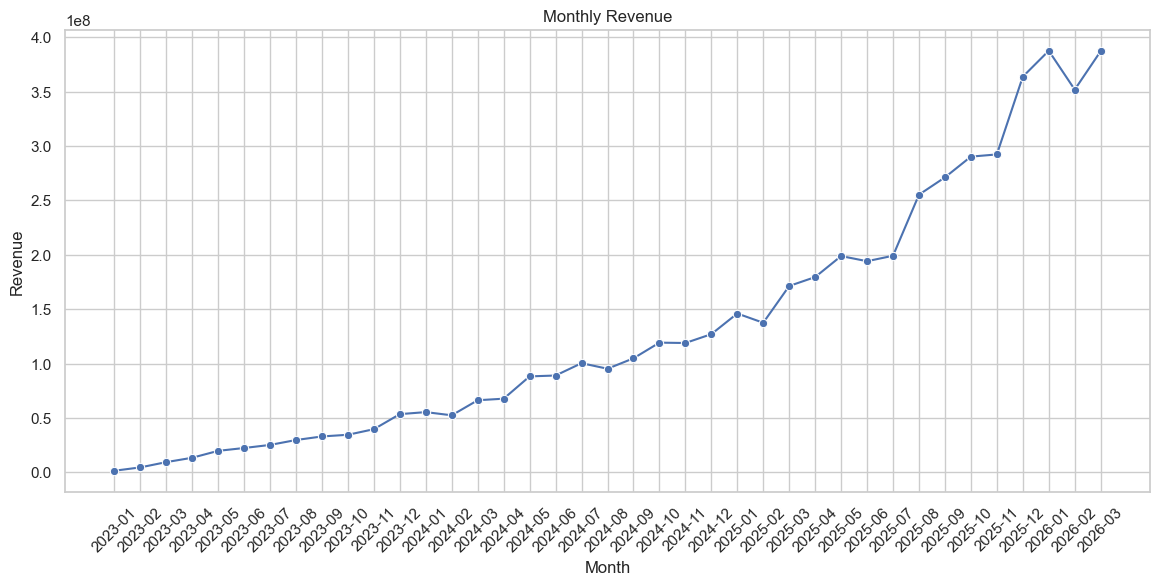

In [12]:
sales["order_month"] = sales["order_date"].dt.to_period("M").astype(str)

revenue_by_month = (
    sales[sales["status"] == "completed"]
    .groupby("order_month", as_index=False)["revenue"]
    .sum()
)

plt.figure(figsize=(14, 6))
sns.lineplot(data=revenue_by_month, x="order_month", y="revenue", marker="o")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [13]:
orders_by_status = orders["status"].value_counts().reset_index()
orders_by_status.columns = ["status", "orders_count"]

orders_by_status

,status,orders_count
0,completed,20462
1,cancelled,2824
2,returned,1714


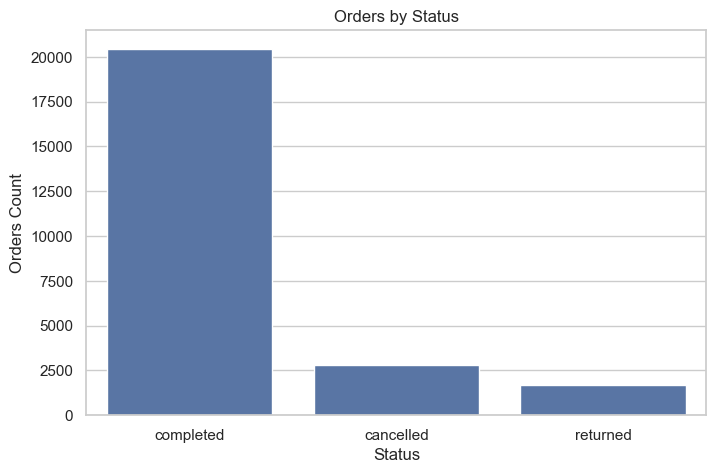

In [14]:
plt.figure(figsize=(8, 5))
sns.barplot(data=orders_by_status, x="status", y="orders_count")
plt.title("Orders by Status")
plt.xlabel("Status")
plt.ylabel("Orders Count")
plt.show()